#### import dependencies

In [9]:
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Conv2D, Dropout, Flatten, Dense
from tensorflow.keras.layers import Activation, MaxPooling2D
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import ReduceLROnPlateau
from livelossplot import PlotLossesKeras
import os

In [10]:
img_size = 48
batch_size = 64
train_data_dir = "fer-2013/train"
test_data_dir = "fer-2013/test"
classes = ['angry','disgust','fear','happy','sad','surprise','neutral']

### Load data images

In [11]:
#training dataset
images = []
labels = []
# list of images and labels from the directory
for sub_dir in os.listdir(train_data_dir):
    category_dir = os.path.join(train_data_dir, sub_dir)
    images_list = os.listdir(category_dir)
    images_list = list(map(lambda img: os.path.join(sub_dir, img), images_list))
    images.extend(images_list)
    labels.extend([sub_dir]*len(images_list))
    
data = pd.DataFrame({
    'images': images,
    'labels': labels
})
# shuffle data
train_df = data.sample(frac=1).reset_index(drop=True)
# train_df = data.iloc[0:10000]

train_df

,images,labels
0,angry/Training_11666027.jpg,angry
1,happy/Training_30447736.jpg,happy
2,happy/Training_77118913.jpg,happy
3,fear/Training_26552601.jpg,fear
4,neutral/Training_26334145.jpg,neutral
...,...,...
28704,neutral/Training_37947064.jpg,neutral
28705,angry/Training_89613328.jpg,angry
28706,surprise/Training_82135051.jpg,surprise
28707,angry/Training_2261453.jpg,angry


In [12]:
# test dataset
images = []
labels = []
# list of images and labels from the directory
for sub_dir in os.listdir(test_data_dir):
    category_dir = os.path.join(test_data_dir, sub_dir)
    images_list = os.listdir(category_dir)
    images_list = list(map(lambda img: os.path.join(sub_dir, img), images_list))
    images.extend(images_list)
    labels.extend([sub_dir]*len(images_list))
    
data = pd.DataFrame({
    'images': images,
    'labels': labels
})
# shuffle data
validation_df = data.sample(frac=1).reset_index(drop=True)
# validation_df = data.iloc[0:2000]

validation_df

,images,labels
0,angry/PublicTest_16745237.jpg,angry
1,surprise/PrivateTest_70595908.jpg,surprise
2,fear/PrivateTest_49873414.jpg,fear
3,angry/PrivateTest_76880087.jpg,angry
4,happy/PrivateTest_54035452.jpg,happy
...,...,...
7173,happy/PublicTest_69207826.jpg,happy
7174,neutral/PublicTest_75671769.jpg,neutral
7175,happy/PublicTest_31512315.jpg,happy
7176,happy/PrivateTest_46585222.jpg,happy


### Data Viualisation

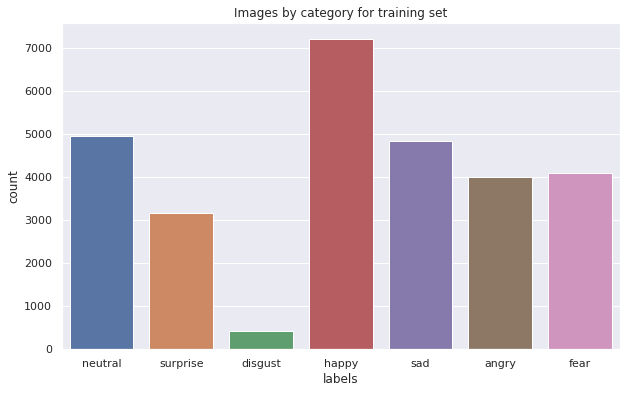

In [21]:
# training dataset
plt.figure(figsize=(10,6))
sns.set()
sns.countplot(data=train_df, x='labels')
plt.title('Images by category for training set')
plt.show()

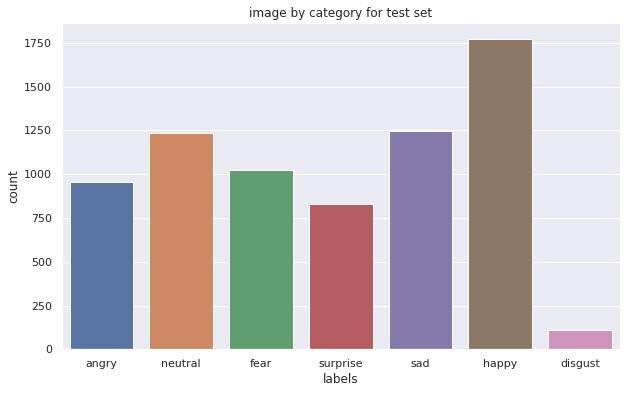

In [23]:
plt.figure(figsize=(10,6))
sns.countplot(data=validation_df,x='labels')
plt.title('image by category for test set')
plt.show()

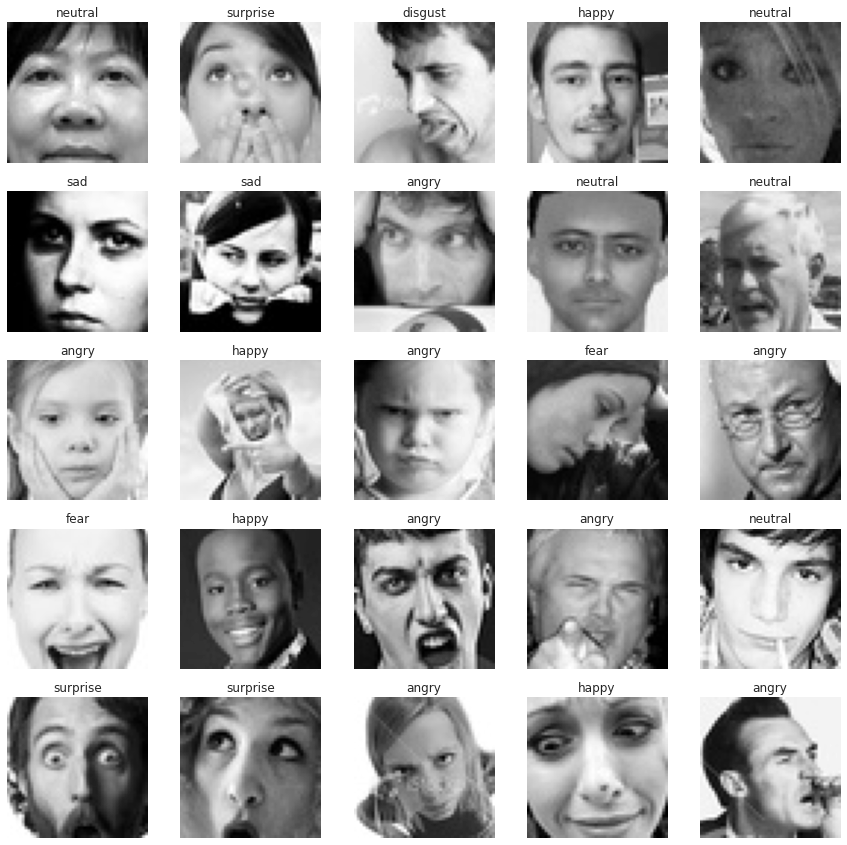

In [40]:
plt.figure(figsize=(15,15))
for i in range(25):
    plt.subplot(5,5,i+1)
    img=plt.imread(os.path.join(train_data_dir,train_df['images'][i]))
    plt.title(train_df['labels'][i])
    plt.imshow(img, cmap='gray')
    plt.axis('off')

#### images data generator

In [41]:
#train gen
train_data_generator = ImageDataGenerator(
    rescale = 1.0/255,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True,
    rotation_range = 60,
)

train_data = train_data_generator.flow_from_dataframe(
    dataframe = train_df,
    directory = train_data_dir,
    x_col = 'images',
    y_col = 'labels',
    batch_size = batch_size,
    seed=0,
    shuffle = True,
    class_mode = 'categorical',
    target_size=(img_size, img_size),
    color_mode = 'grayscale'
)

# test gen
validation_data_generator = ImageDataGenerator(
    rescale = 1.0/255,
)

validation_data = validation_data_generator.flow_from_dataframe(
    dataframe = validation_df,
    directory = test_data_dir,
    x_col = 'images',
    y_col = 'labels',
    batch_size = batch_size,
    seed=0,
    shuffle = True,
    class_mode = 'categorical',
    target_size=(img_size, img_size),
    color_mode = 'grayscale'
)

Found 28709 validated image filenames belonging to 7 classes.
Found 7178 validated image filenames belonging to 7 classes.


### Build the CNN model

In [42]:
emotion_model = Sequential()

# conv 1
emotion_model.add(Conv2D(filters=16, kernel_size=(3,3), padding='same', input_shape=(img_size, img_size,1)))
# emotion_model.add(BatchNormalization())
emotion_model.add(Activation('relu'))
emotion_model.add(MaxPooling2D(pool_size=(2,2), strides=(1,1)))

# conv 2
emotion_model.add(Conv2D(filters=32, kernel_size=(3,3), padding='same'))
# emotion_model.add(BatchNormalization())
emotion_model.add(Activation('relu'))
emotion_model.add(MaxPooling2D(pool_size=(2,2), strides=(1,1)))

# conv 3
emotion_model.add(Conv2D(filters=64, kernel_size=(3,3), padding='same'))
# emotion_model.add(BatchNormalization())
emotion_model.add(Activation('relu'))
emotion_model.add(MaxPooling2D(pool_size=(2,2), strides=(1,1)))

# conv 4
emotion_model.add(Conv2D(filters=128, kernel_size=(3,3), padding='same'))
# emotion_model.add(BatchNormalization())
emotion_model.add(Activation('relu'))
emotion_model.add(MaxPooling2D(pool_size=(2,2), strides=(1,1)))

# flatten
emotion_model.add(Flatten())

# fully connected 1
emotion_model.add(Dense(512))
emotion_model.add(BatchNormalization())
emotion_model.add(Activation('relu'))
emotion_model.add(Dropout(0.3))

# fully connected 2
emotion_model.add(Dense(256))
emotion_model.add(BatchNormalization())
emotion_model.add(Activation('relu'))
emotion_model.add(Dropout(0.25))

# fully connected 3
emotion_model.add(Dense(128))
emotion_model.add(BatchNormalization())
emotion_model.add(Activation('relu'))
emotion_model.add(Dropout(0.2))

# output block
emotion_model.add(Dense(7, activation='softmax'))

2022-04-05 11:59:11.180930: I tensorflow/compiler/jit/xla_cpu_device.cc:41] Not creating XLA devices, tf_xla_enable_xla_devices not set
2022-04-05 11:59:11.460069: I tensorflow/core/common_runtime/process_util.cc:146] Creating new thread pool with default inter op setting: 2. Tune using inter_op_parallelism_threads for best performance.


In [51]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
emotion_model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
emotion_model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 48, 48, 16)        160       
_________________________________________________________________
activation (Activation)      (None, 48, 48, 16)        0         
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 47, 47, 16)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 47, 47, 32)        4640      
_________________________________________________________________
activation_1 (Activation)    (None, 47, 47, 32)        0         
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 46, 46, 32)        0         
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 46, 46, 64)        1

#### train the model

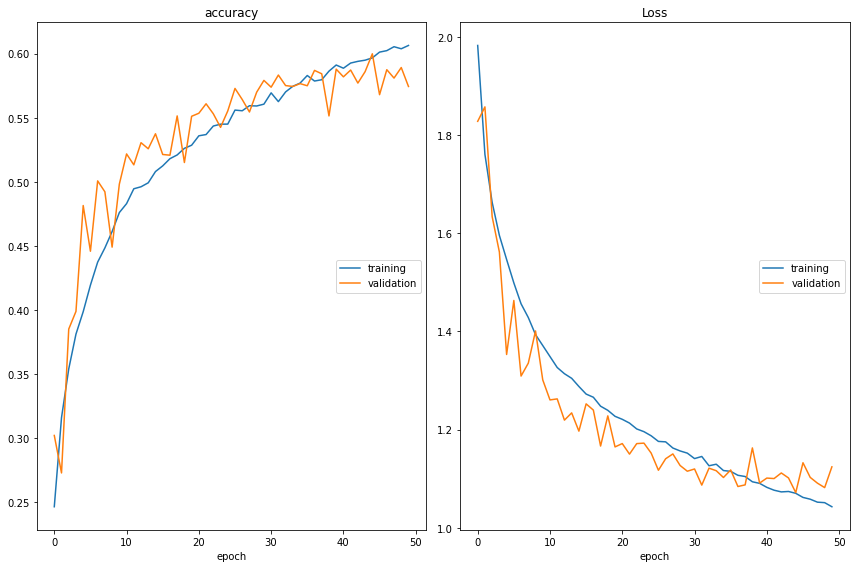

accuracy
	training         	 (min:    0.246, max:    0.606, cur:    0.606)
	validation       	 (min:    0.273, max:    0.600, cur:    0.574)
Loss
	training         	 (min:    1.043, max:    1.983, cur:    1.043)
	validation       	 (min:    1.072, max:    1.858, cur:    1.124)

449/449 [==============================] - 739s 2s/step - loss: 1.0429 - accuracy: 0.6064 - val_loss: 1.1242 - val_accuracy: 0.5744 - lr: 1.0000e-04


In [16]:
# train the model
epochs = 50
reduce_lrate = ReduceLROnPlateau(monitor='val_loss', factor=0.1, pacience=2, min_lr=1e-5, model='auto')
model_callbacks = [PlotLossesKeras(), reduce_lrate]
emotion_model.fit(
    train_data,
    epochs = epochs,
    batch_size = batch_size,
    validation_data = validation_data,
    callbacks = model_callbacks
)

#### save the model

In [11]:
# save the model
emotion_model.save('../../models/model_v2.h5')

json_model = emotion_model.to_json()
with open('../../models/model_v2.json', 'w') as json_file:
    json_file.write(json_model)
    
emotion_model.save_weights('../../models/model_v2_weights.h5')

### Evaluation metrics

In [2]:
from tensorflow.keras.models import load_model,  model_from_json
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [60]:
json_file = open('../../models/model_v2.json', 'r')
model = json_file.read()
json_file.close()
model = model_from_json(model)
model.load_weights("../../models/model_v2_weights.h5")
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
train_loss, train_accuracy = model.evaluate(train_data)
test_loss, test_accuracy = model.evaluate(validation_data)

In [113]:
print('--------- training ---------')
print('- emotion model accuracy : ', train_accuracy)
print('- emlotion model loss: ', train_loss)
print('--------- test ---------')
print('- emotion model accuracy : ', test_accuracy)
print('- emlotion model loss: ', test_loss)

--------- training ---------
- emotion model accuracy :  0.6355149745941162
- emlotion model loss:  0.9695436358451843
--------- test ---------
- emotion model accuracy :  0.5743939876556396
- emlotion model loss:  1.1242187023162842


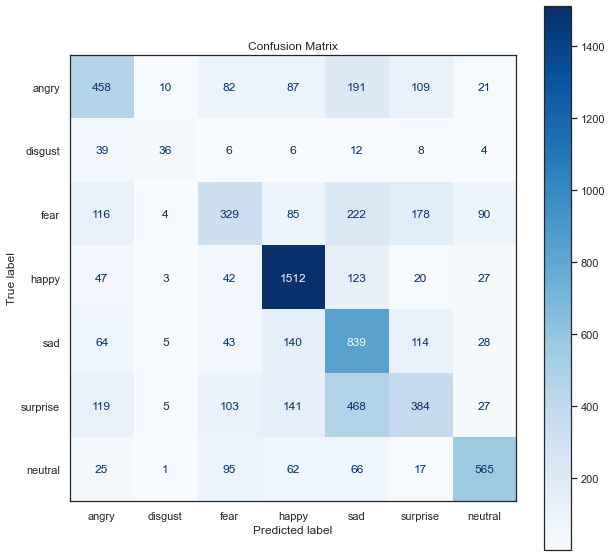

In [114]:
y_true = validation_data.classes
pred = model.predict(validation_data)
y_pred = np.argmax(pred, axis=1)
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(10, 10))
plt.title('Confusion Matrix')
disp.plot(cmap='Blues',ax=ax)
plt.show()

In [115]:
print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.53      0.48      0.50       958
           1       0.56      0.32      0.41       111
           2       0.47      0.32      0.38      1024
           3       0.74      0.85      0.79      1774
           4       0.44      0.68      0.53      1233
           5       0.46      0.31      0.37      1247
           6       0.74      0.68      0.71       831

    accuracy                           0.57      7178
   macro avg       0.56      0.52      0.53      7178
weighted avg       0.57      0.57      0.56      7178



### test the model

In [5]:
json_file = open('../../models/model.json', 'r')
model = json_file.read()
json_file.close()
model = model_from_json(model)
model.load_weights("../../models/model_weights.h5")
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [ ]:
plt.figure(figsize=(15,15))
for i in range(25):
    plt.subplot(5,5,i+1)
    img=plt.imread(os.path.join(train_data_dir,train_df['images'][i]))
    plt.title(train_df['labels'][i])
    plt.imshow(img, cmap='gray')
    plt.axis('off')

(7, 48, 48, 1)


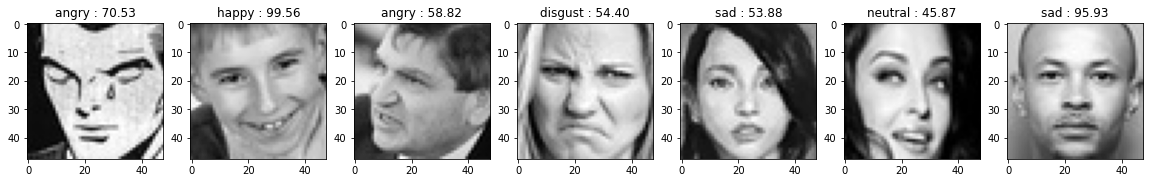

In [19]:
test_images = []
for i in range(7):
    n = np.random.randint(0,7000)
    img = plt.imread(os.path.join(test_data_dir,validation_df['images'][n]))
    test_images.append(img)
    
test_images = np.array(test_images)
test_images = np.array(test_images).reshape(-1,48,48,1)
print(test_images.shape)

predictions = model.predict(test_images)
plt.figure(figsize=(20,5))
for i in range(len(test_images)):
    plt.subplot(1,7,i+1)
    plt.imshow(test_images[i], cmap='gray')
    p = predictions[i].max()*100.00
    emotion_index = np.argmax(predictions[i])
    emotion_label = classes[emotion_index]
    plt.title("{} : {:.2f}".format(emotion_label, p))